In [38]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [39]:
# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cpu


In [40]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "sam2_hiera_tiny.pt"
model_cfg = "sam2_hiera_t.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

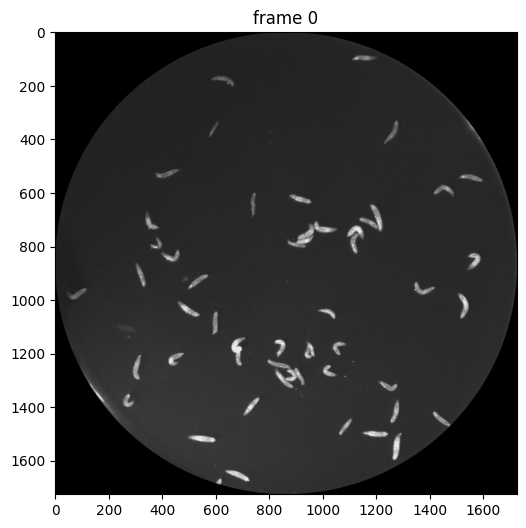

In [42]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "frames_cropped"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [43]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 51/51 [00:07<00:00,  6.96it/s]


In [44]:
predictor.reset_state(inference_state)

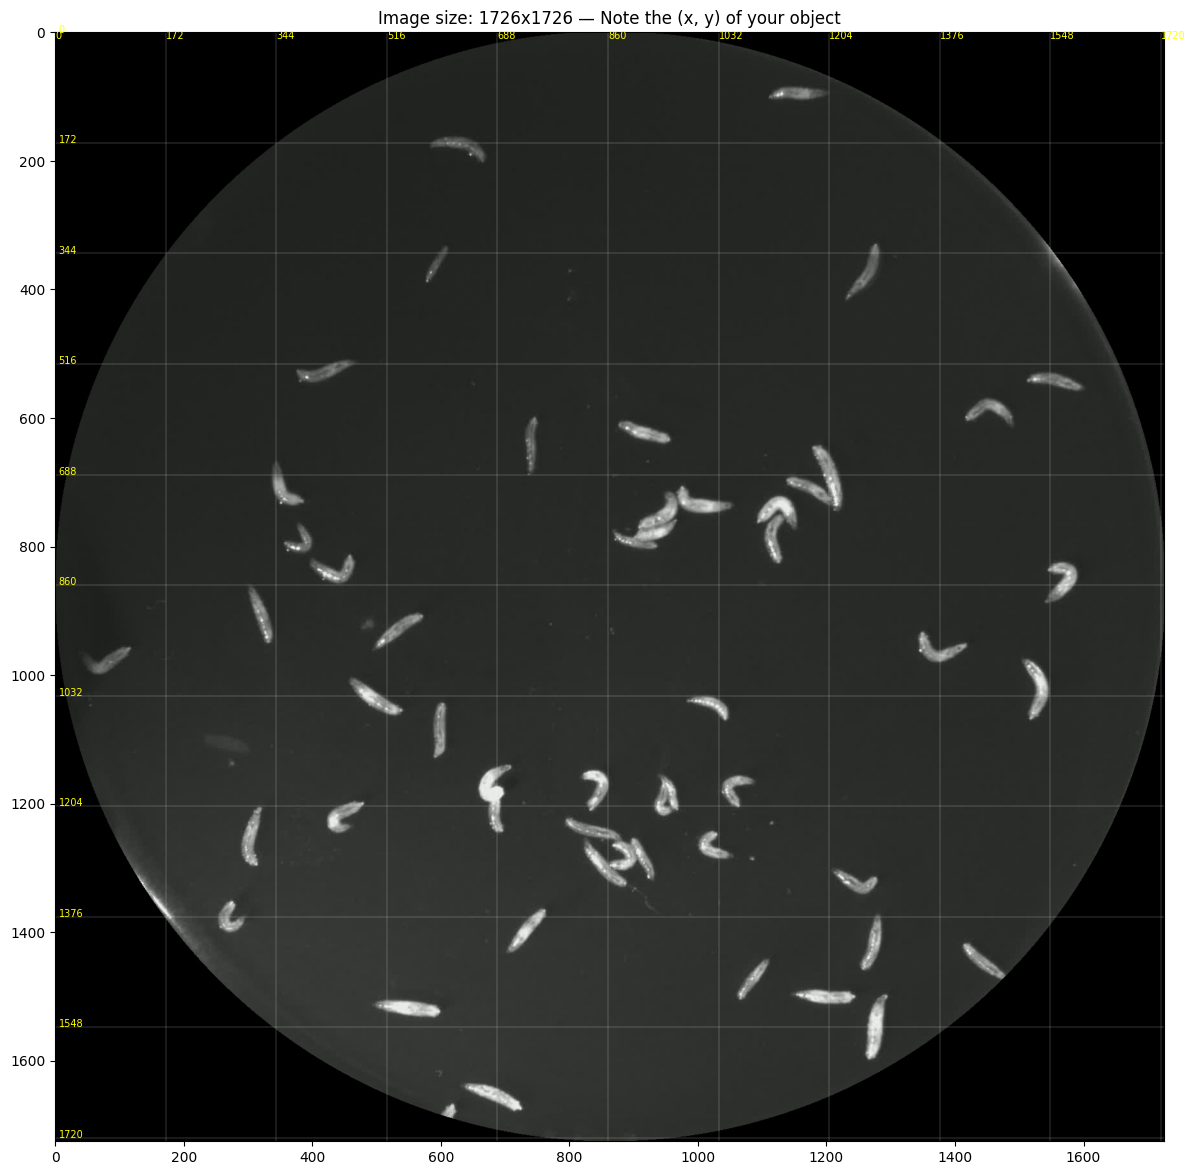

In [45]:
video_dir = "frames_cropped"
frames = sorted(os.listdir(video_dir))
first_frame = cv2.imread(os.path.join(video_dir, frames[0]))
first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

# --- Show image with grid and coordinates to help you pick ---
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(first_frame_rgb)

# Add grid
h, w = first_frame_rgb.shape[:2]
step_x, step_y = w // 10, h // 10
for x in range(0, w, step_x):
    ax.axvline(x, color='white', linewidth=0.3, alpha=0.5)
    ax.text(x, 10, str(x), color='yellow', fontsize=7)
for y in range(0, h, step_y):
    ax.axhline(y, color='white', linewidth=0.3, alpha=0.5)
    ax.text(5, y, str(y), color='yellow', fontsize=7)

ax.set_title(f"Image size: {w}x{h} — Note the (x, y) of your object")
plt.tight_layout()
plt.savefig("reference_with_grid.png", dpi=150)
plt.show()

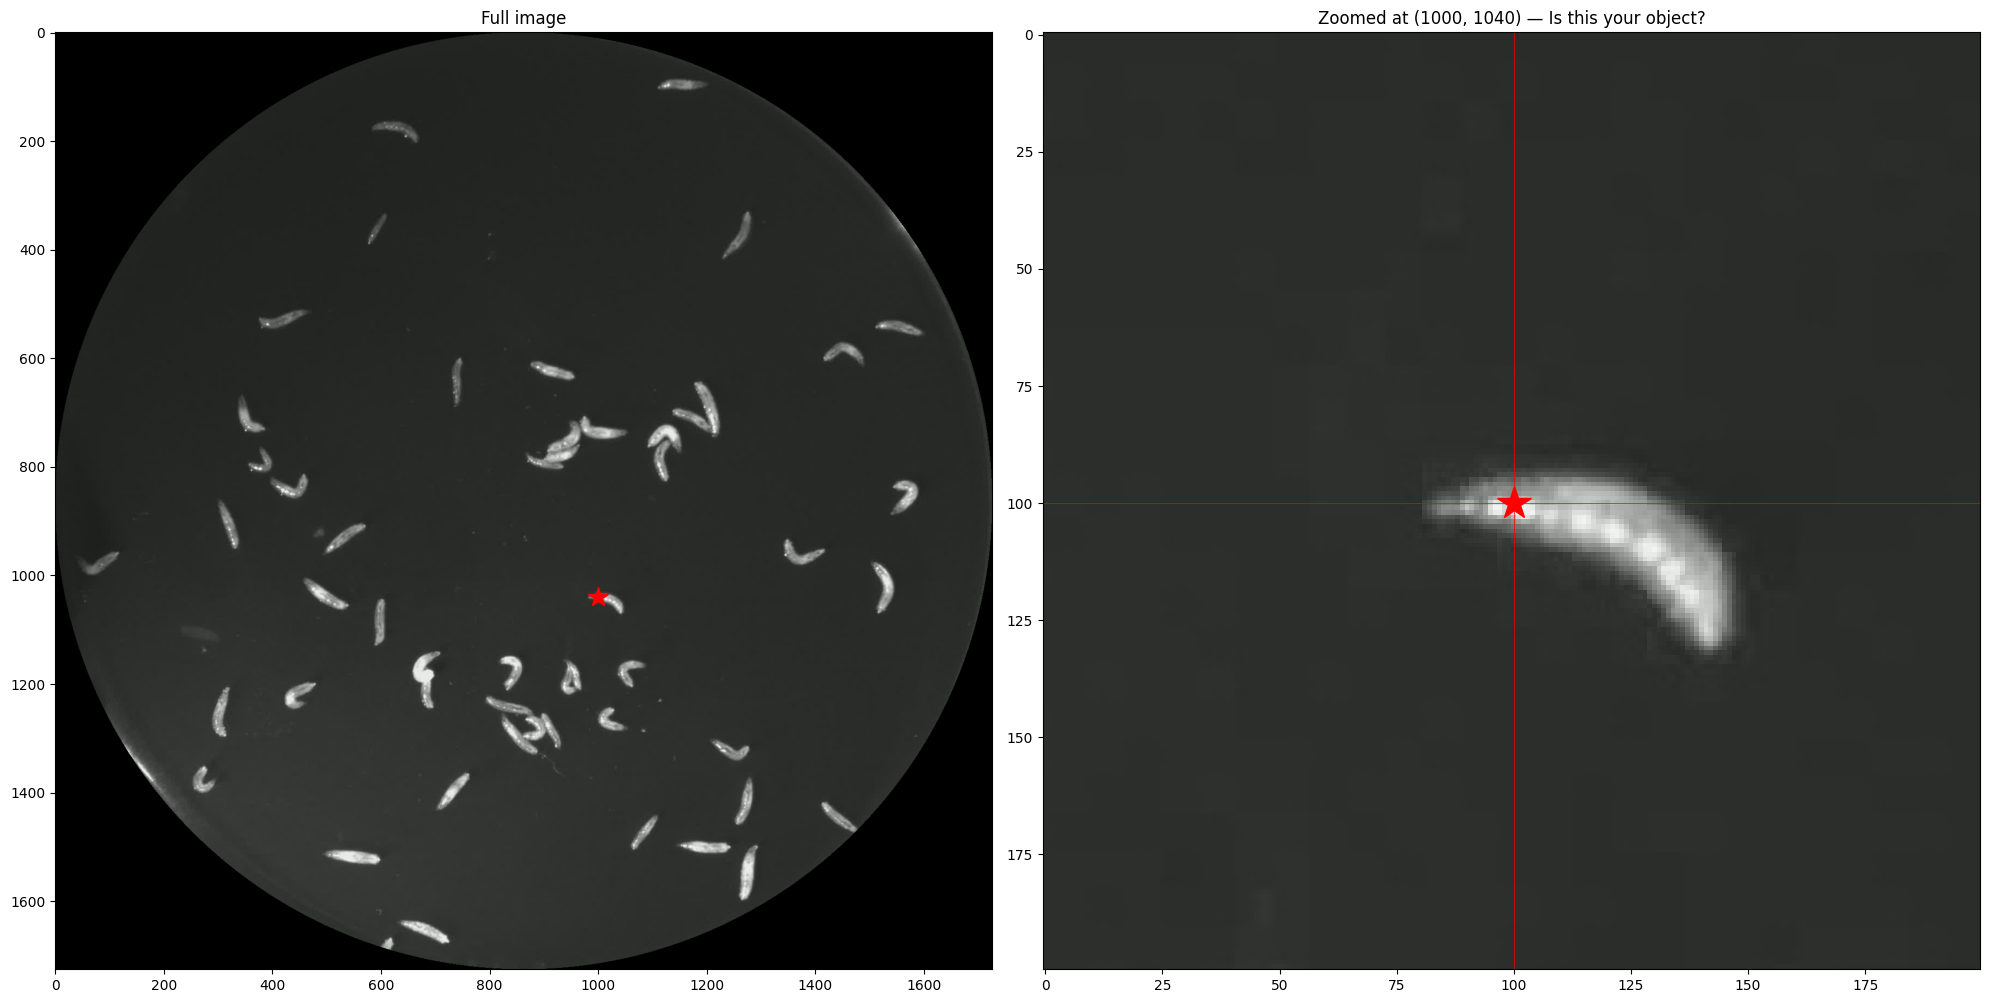

In [46]:
# ============================================
# NOW SET EXACT COORDINATES FROM ZOOMED VIEW
# ============================================
clicks = [[1000, 1040]]  # <-- your exact (x, y)
# ============================================

# --- Verify with zoomed view ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Full image with marker
axes[0].imshow(first_frame_rgb)
for x, y in clicks:
    axes[0].plot(x, y, 'r*', markersize=15)
axes[0].set_title("Full image")

# Zoomed around click
zoom = 100
for x, y in clicks:
    zx1 = max(x - zoom, 0)
    zx2 = min(x + zoom, w)
    zy1 = max(y - zoom, 0)
    zy2 = min(y + zoom, h)
    
    cropped = first_frame_rgb[zy1:zy2, zx1:zx2]
    axes[1].imshow(cropped)
    # Draw crosshair at click position within crop
    cx = x - zx1
    cy = y - zy1
    axes[1].axvline(cx, color='red', linewidth=0.5)
    axes[1].axhline(cy, color='red', linewidth=0.5)
    axes[1].plot(cx, cy, 'r*', markersize=25)
    axes[1].set_title(f"Zoomed at ({x}, {y}) — Is this your object?")

plt.tight_layout()
plt.show()

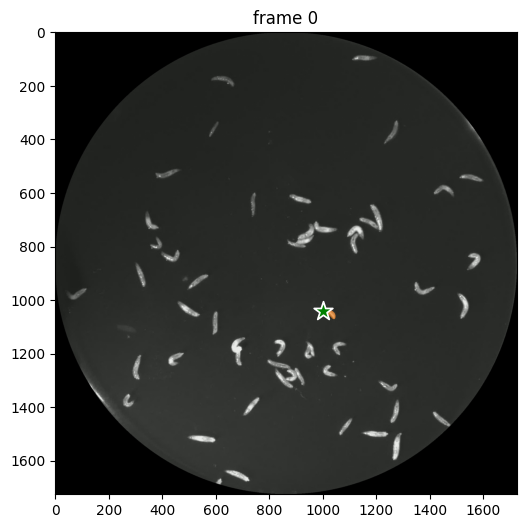

In [47]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

# Let's add a positive click at (x, y) = (210, 350) to get started
points = np.array([[1000, 1040]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

propagate in video: 100%|██████████| 51/51 [10:57<00:00, 12.89s/it]


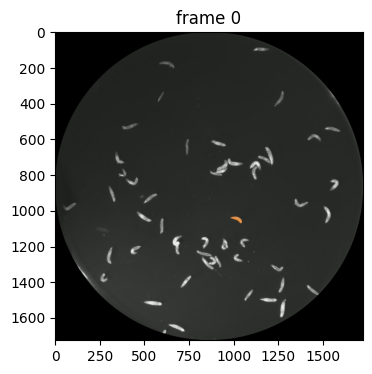

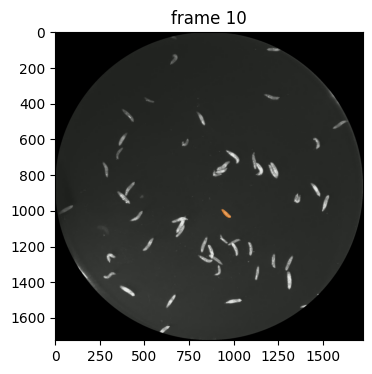

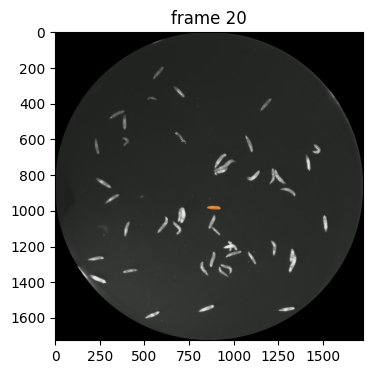

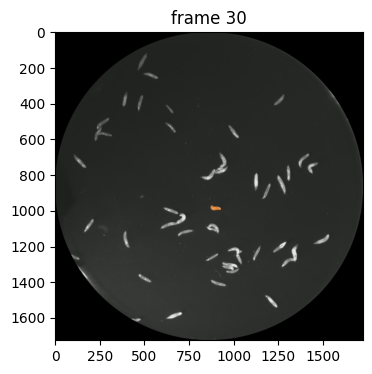

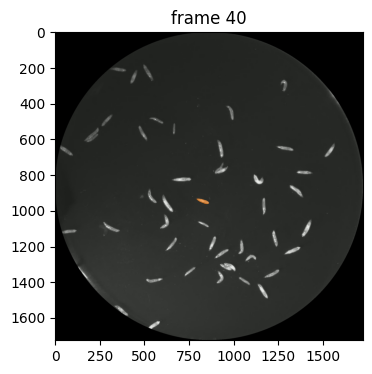

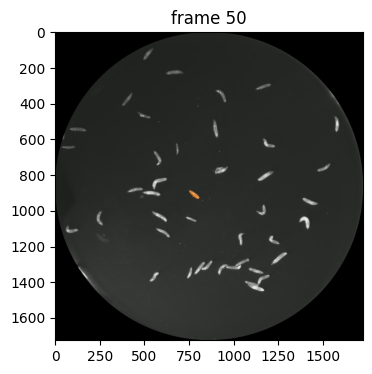

In [48]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 10
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

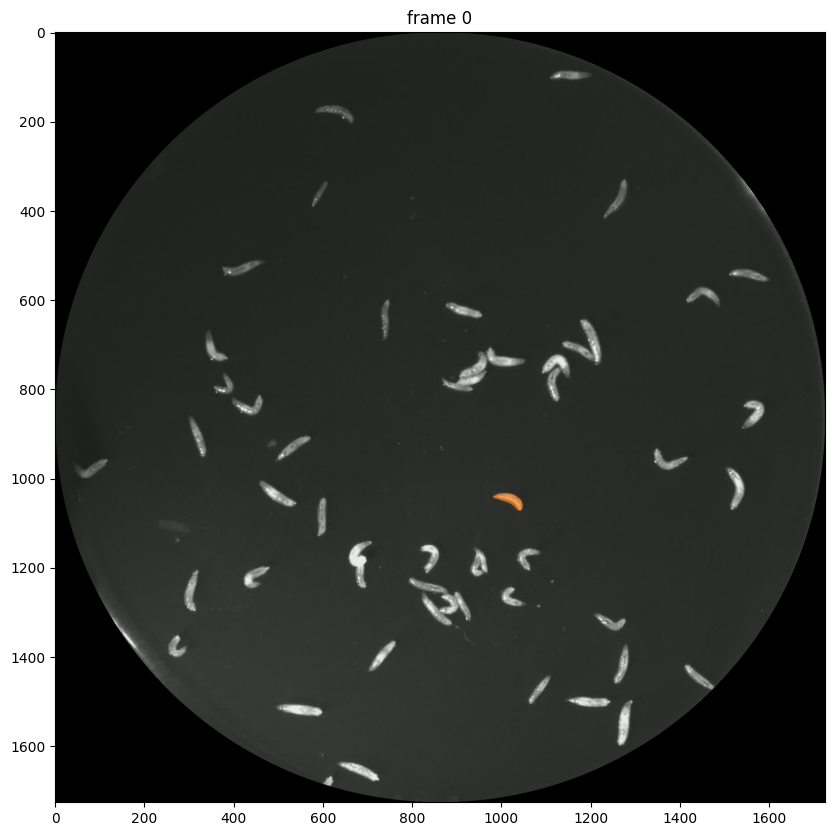

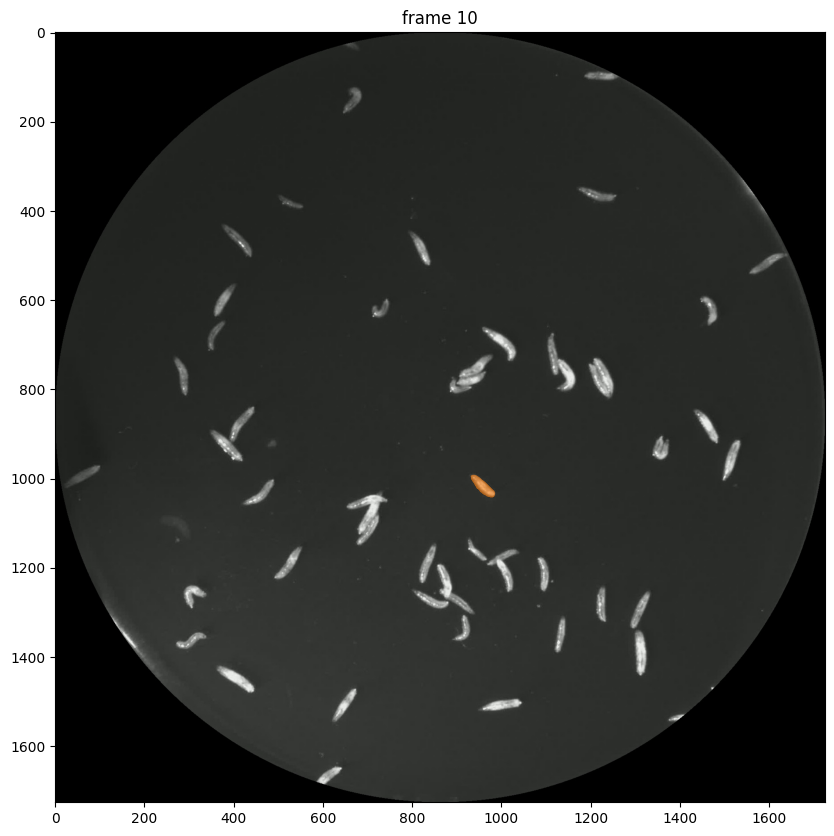

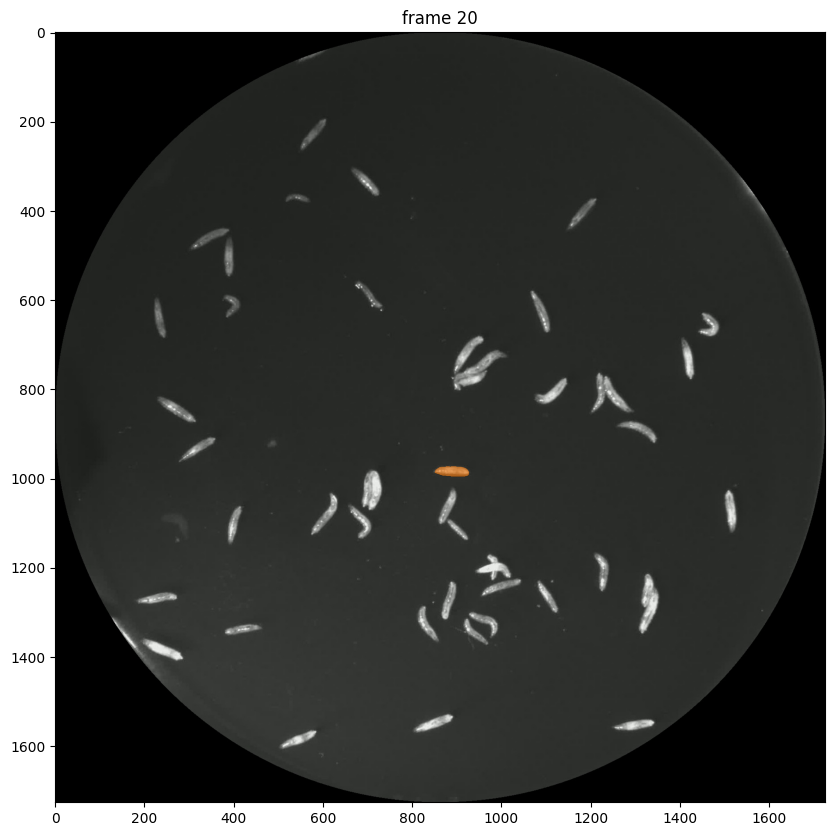

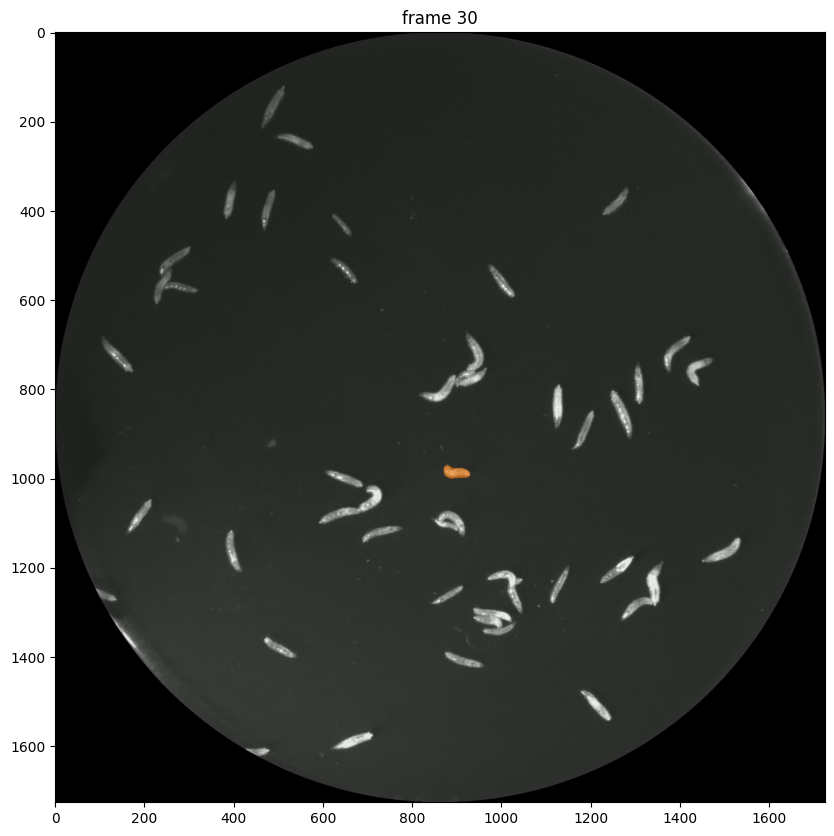

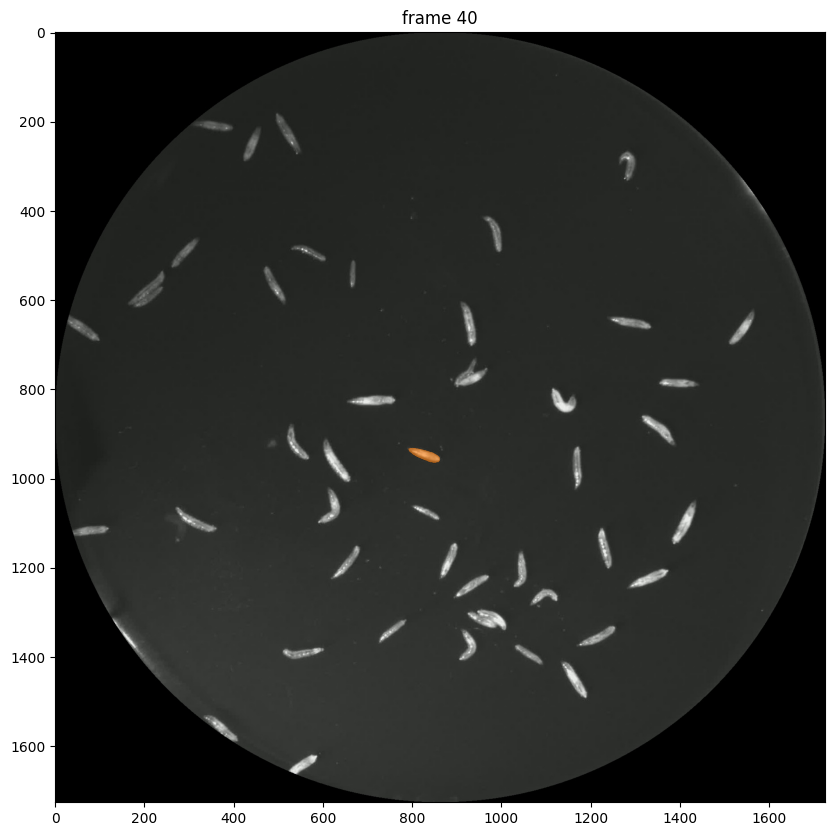

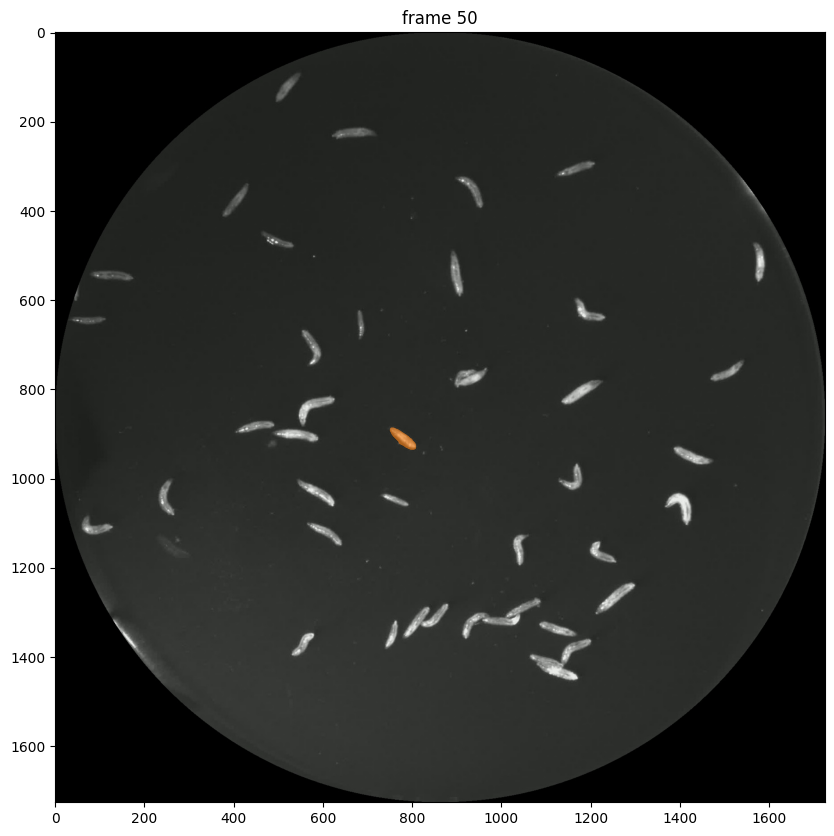

In [49]:
# render the segmentation results every few frames
vis_frame_stride = 10
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(15, 10))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)